<a href="https://colab.research.google.com/github/Patrick190508/whaleshark-mafia-island/blob/main/notebooks/MVP_Daily_Prediction_Ningaloo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Daily whale shark encounter prediction, Ningaloo Reef
**Minimum viable project: one site, the models of the Veritas Scholars course, one honest evaluation.**

Two versions of the question are tested on the same data:

- **Version 1 — "Will at least one whale shark be sighted today?"** (yes / no)
- **Version 2 — "Will today be a better-than-average day for its season?"** (sightings above the mean of that season)

**Data.** OBIS human sightings matched to daily Copernicus values (`daily_ningaloo.csv`): SST, chlorophyll-a, salinity and **wind speed** (daily mean, from hourly KNMI L4 wind). Peak season April–June, active seasons only (≥ 20 sightings). Days without a record count as 0 sightings — the observation-effort limitation.

**Models** (all from the course):

| Model | Course | Role |
|---|---|---|
| Weekly baseline | — | share of positive days per week of season (the calendar) |
| Logistic regression | Week 4 | linear, interpretable: one coefficient per variable |
| Logistic regression + squared terms (`sday²`, `SST²`) | Week 3 | lets the model find an optimum (the bell shape of the season) |
| Small neural network, 1 hidden layer (4 / 8 / 16 units) | Week 6 | non-linear challenger: interactions between variables |

Trivial references: "always yes" (v1) and "always no" (v2), i.e. the majority class. Decision threshold tuned with the confusion matrix on the validation set (FP = empty trip, FN = missed good day).

**Validation.** Training (1998–2004) / validation (2005–2006) / test (2007–2009) sets split by season — never at random. The test set is used once, at the end of each version.

## 1. Data

### 1.1 Load the daily series and build the season table
One row per day of the season with that day's environmental values, day of season, week, and both targets.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/daily_ningaloo.csv"
d = pd.read_csv(URL, parse_dates=["date"])

PEAK = [4, 5, 6]                                   # Ningaloo season: April–June
d = d[d["month"].isin(PEAK)].copy()
d["sday"] = d.groupby("year").cumcount() + 1       # day of season 1..91
d["week"] = (d["sday"] - 1) // 7 + 1

# active seasons only (>= 20 sightings), as in the EDA
tot = d.groupby("year")["sightings"].sum()
active = tot[tot >= 20].index
d = d[d["year"].isin(active)].dropna(subset=["sst", "chl", "sss", "wind"]).copy()

# squared terms for the polynomial model (Week 3)
d["sday2"] = d["sday"] ** 2
d["sst2"]  = d["sst"] ** 2

# target v1: at least one sighting that day
d["y1"] = (d["sightings"] > 0).astype(int)

# target v2: better-than-average day for its own season
avg = d.groupby("year")["sightings"].transform("mean")
d["y2"] = (d["sightings"] > avg).astype(int)

print("seasons:", sorted(d["year"].unique()))
print("rows:", len(d))
print("v1 — days with >= 1 sighting:", d["y1"].sum(), f"({d['y1'].mean():.0%})")
print("v2 — better-than-average days:", d["y2"].sum(), f"({d['y2'].mean():.0%})")

seasons: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009)]
rows: 1092
v1 — days with >= 1 sighting: 748 (68%)
v2 — better-than-average days: 404 (37%)


### 1.2 Train / validation / test split by season
Earliest seasons → training; two later seasons → validation (to tune); most recent seasons → test (used once).

In [2]:
TRAIN = list(range(1998, 2005))
VAL   = [2005, 2006]
TEST  = [2007, 2008, 2009]

train = d[d["year"].isin(TRAIN)]
val   = d[d["year"].isin(VAL)]
test  = d[d["year"].isin(TEST)]

for name, part in [("train", train), ("validation", val), ("test", test)]:
    print(f"{name:11s} seasons {part['year'].min()}–{part['year'].max()} | days {len(part):4d} | "
          f"v1 share {part['y1'].mean():.0%} | v2 share {part['y2'].mean():.0%}")

train       seasons 1998–2004 | days  637 | v1 share 55% | v2 share 33%
validation  seasons 2005–2006 | days  182 | v1 share 81% | v2 share 43%
test        seasons 2007–2009 | days  273 | v1 share 90% | v2 share 42%


### 1.3 Scoring function and feature matrices
Accuracy and confusion matrix. FP = empty trip (predicted good, was not); FN = missed good day.

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def score(y_true, p, thr=0.5, label=""):
    pred = (np.asarray(p) >= thr).astype(int)
    acc = accuracy_score(y_true, pred)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    print(f"{label:26s} acc {acc:.2f} | TP {tp:3d} FP {fp:3d} FN {fn:3d} TN {tn:3d}")
    return acc

FEATS  = ["sday", "sst", "chl", "sss", "wind"]                       # linear
FEATS2 = ["sday", "sday2", "sst", "sst2", "chl", "sss", "wind"]      # with squared terms

sc1 = StandardScaler().fit(train[FEATS])
Xtr1, Xva1, Xte1 = (sc1.transform(p[FEATS]) for p in (train, val, test))
sc2 = StandardScaler().fit(train[FEATS2])
Xtr2, Xva2, Xte2 = (sc2.transform(p[FEATS2]) for p in (train, val, test))

def weekly_baseline(y):
    """share of positive days per week of season, from the training seasons"""
    return train.groupby("week")[y].mean().rename("p_week")

def coef_plot(model, feats, title):
    coef = pd.Series(model.coef_[0], index=feats).sort_values()
    print(coef.round(2))
    coef.plot(kind="barh", color="steelblue", figsize=(6, 3))
    plt.axvline(0, color="grey"); plt.title(title); plt.show()

## 2. Version 1 — "Will at least one whale shark be sighted today?"

### 2.1 Weekly baseline

week
1     0.45
2     0.61
3     0.69
4     0.69
5     0.67
6     0.59
7     0.59
8     0.61
9     0.67
10    0.57
11    0.41
12    0.29
13    0.35
Name: p_week, dtype: float64


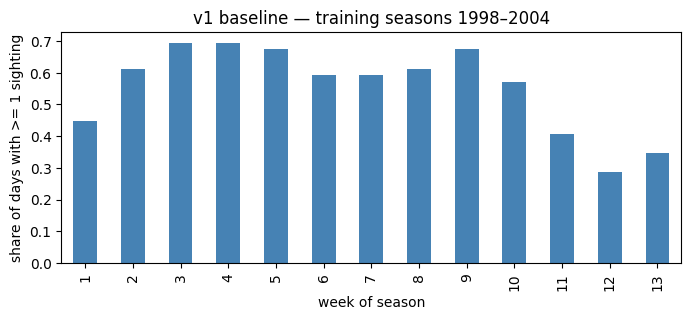

In [4]:
wk1 = weekly_baseline("y1")
print(wk1.round(2))
wk1.plot(kind="bar", color="steelblue", figsize=(8, 3))
plt.ylabel("share of days with >= 1 sighting"); plt.xlabel("week of season")
plt.title("v1 baseline — training seasons 1998–2004"); plt.show()

p_val_base1  = val["week"].map(wk1)
p_test_base1 = test["week"].map(wk1)

### 2.2 Logistic regression, with and without `year`

with year:
wind   -0.25
sss    -0.05
chl     0.16
sday    0.27
sst     0.77
year    1.34
dtype: float64


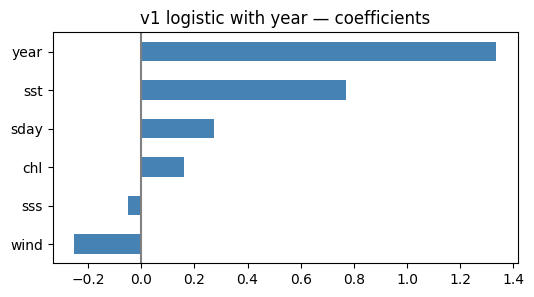

logistic + year (val)      acc 0.81 | TP 148 FP  34 FN   0 TN   0

without year:
sday   -0.84
sst    -0.42
wind   -0.30
sss     0.22
chl     0.42
dtype: float64


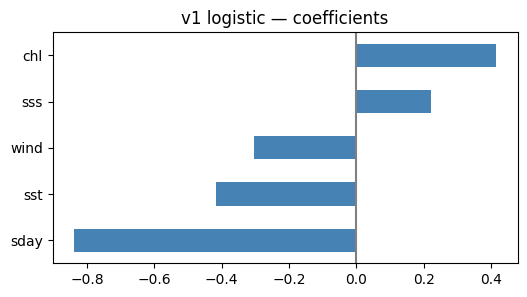

In [5]:
y1_tr, y1_va, y1_te = train["y1"], val["y1"], test["y1"]

# with year (to show what happens)
FY = FEATS + ["year"]
scy = StandardScaler().fit(train[FY])
logit_y = LogisticRegression(max_iter=1000).fit(scy.transform(train[FY]), y1_tr)
print("with year:"); coef_plot(logit_y, FY, "v1 logistic with year — coefficients")
score(y1_va, logit_y.predict_proba(scy.transform(val[FY]))[:, 1], 0.5, "logistic + year (val)")

# without year
logit1 = LogisticRegression(max_iter=1000).fit(Xtr1, y1_tr)
p_val_l1 = logit1.predict_proba(Xva1)[:, 1]
print("\nwithout year:"); coef_plot(logit1, FEATS, "v1 logistic — coefficients")

*Reading:* With `year` in the inputs it is the strongest coefficient by far: the share of days with a sighting rises from 55% (1998) to 90% (2009) because the photo-ID catalogue grows, and the model extrapolates that trend into the validation seasons, predicting "yes" on every day. `year` is effort, not ecology, and is dropped.

### 2.3 Logistic regression with squared terms

sday2   -1.88
sst2    -0.76
wind    -0.36
sst      0.07
sss      0.20
chl      0.42
sday     0.76
dtype: float64


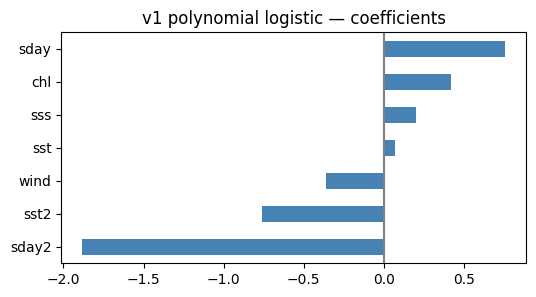

In [6]:
logit1p = LogisticRegression(max_iter=1000).fit(Xtr2, y1_tr)
p_val_l1p = logit1p.predict_proba(Xva2)[:, 1]
coef_plot(logit1p, FEATS2, "v1 polynomial logistic — coefficients")

### 2.4 Threshold tuning on the validation set — all models at equal thresholds

In [7]:
for thr in [0.3, 0.4, 0.5, 0.6]:
    score(y1_va, p_val_base1, thr, f"baseline thr {thr}")
    score(y1_va, p_val_l1,    thr, f"logistic thr {thr}")
    score(y1_va, p_val_l1p,   thr, f"poly-logistic thr {thr}")
    print()
score(y1_va, np.ones(len(val)), label="always 'yes' (val)")

baseline thr 0.3           acc 0.77 | TP 137 FP  31 FN  11 TN   3
logistic thr 0.3           acc 0.80 | TP 146 FP  34 FN   2 TN   0
poly-logistic thr 0.3      acc 0.77 | TP 135 FP  28 FN  13 TN   6

baseline thr 0.4           acc 0.76 | TP 129 FP  25 FN  19 TN   9
logistic thr 0.4           acc 0.73 | TP 125 FP  26 FN  23 TN   8
poly-logistic thr 0.4      acc 0.71 | TP 120 FP  25 FN  28 TN   9

baseline thr 0.5           acc 0.68 | TP 108 FP  18 FN  40 TN  16
logistic thr 0.5           acc 0.63 | TP  99 FP  18 FN  49 TN  16
poly-logistic thr 0.5      acc 0.65 | TP 102 FP  18 FN  46 TN  16

baseline thr 0.6           acc 0.46 | TP  67 FP  17 FN  81 TN  17
logistic thr 0.6           acc 0.47 | TP  65 FP  14 FN  83 TN  20
poly-logistic thr 0.6      acc 0.52 | TP  72 FP  11 FN  76 TN  23

always 'yes' (val)         acc 0.81 | TP 148 FP  34 FN   0 TN   0


0.8131868131868132

*Reading:* The linear model is worse than the weekly baseline at every threshold: a straight line cannot describe a season that rises, peaks and falls. With squared terms (`sday²`) the model reproduces the bell shape and matches the baseline, but never beats it consistently. Both are below "always yes" (0.81), because 81% of validation days have a sighting. Threshold 0.3 is chosen for the test.

### 2.5 Test (used once)

In [8]:
p_test_l1p = logit1p.predict_proba(Xte2)[:, 1]
score(y1_te, p_test_base1, 0.3, "baseline thr 0.3 (test)")
score(y1_te, p_test_l1p,   0.3, "poly-logistic thr 0.3 (test)")
score(y1_te, np.ones(len(test)), label="always 'yes' (test)")

baseline thr 0.3 (test)    acc 0.84 | TP 228 FP  24 FN  19 TN   2
poly-logistic thr 0.3 (test) acc 0.84 | TP 223 FP  21 FN  24 TN   5
always 'yes' (test)        acc 0.90 | TP 247 FP  26 FN   0 TN   0


0.9047619047619048

*Reading:* Baseline 0.84, polynomial logistic 0.84, "always yes" 0.90. The model finds 5 empty days out of 26 and misses 24 good ones: a slightly worse version of "always yes".

**Conclusion of version 1.** In the peak season 80–90% of days have a sighting, so the best answer to "will a shark be seen?" is "yes, go out" — which is what operators already do. The question has no information left in it. It has to be changed.

## 3. Version 2 — "Will today be a better-than-average day for its season?"

Target: `y2` = 1 if the day's sightings are above the **mean of its own season**, 0 otherwise. Every season is compared with itself, so the growth of the catalogue no longer matters and the share of positive days is stable (about 35–45%). The trivial reference is now "always no" (the majority class).

### 3.1 Weekly baseline

week
1     0.16
2     0.29
3     0.41
4     0.47
5     0.43
6     0.37
7     0.45
8     0.39
9     0.41
10    0.35
11    0.18
12    0.20
13    0.18
Name: p_week, dtype: float64


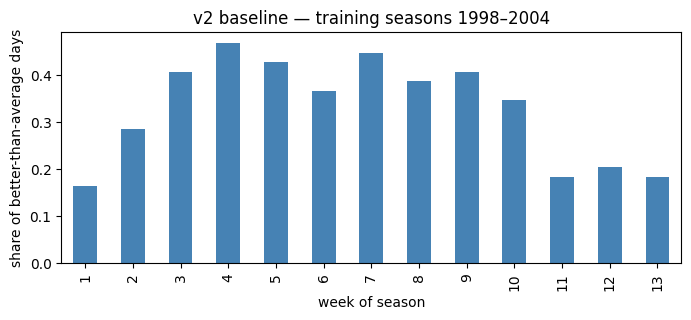

In [9]:
y2_tr, y2_va, y2_te = train["y2"], val["y2"], test["y2"]

wk2 = weekly_baseline("y2")
print(wk2.round(2))
wk2.plot(kind="bar", color="steelblue", figsize=(8, 3))
plt.ylabel("share of better-than-average days"); plt.xlabel("week of season")
plt.title("v2 baseline — training seasons 1998–2004"); plt.show()

p_val_base2  = val["week"].map(wk2)
p_test_base2 = test["week"].map(wk2)

         days  share_good
wclass                   
0–3        64        0.33
3–5       240        0.35
5–7       225        0.33
7–10      105        0.29
>10 m/s     3        0.00


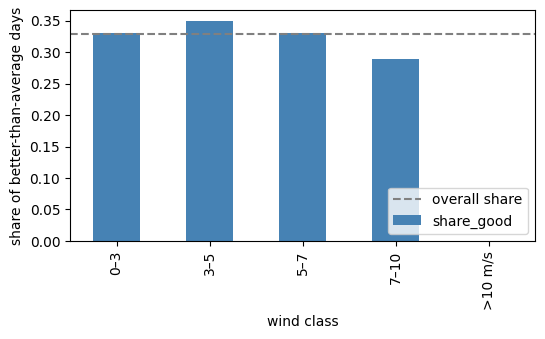

In [10]:
# 3.1b Wind on good vs normal days (training seasons)
bins = [0, 3, 5, 7, 10, 99]
labels = ["0–3", "3–5", "5–7", "7–10", ">10 m/s"]
train_w = train.assign(wclass=pd.cut(train["wind"], bins=bins, labels=labels))
tab = train_w.groupby("wclass", observed=True)["y2"].agg(days="size", share_good="mean").round(2)
print(tab)
tab["share_good"].plot(kind="bar", color="steelblue", figsize=(6, 3))
plt.axhline(train["y2"].mean(), color="grey", ls="--", label="overall share")
plt.ylabel("share of better-than-average days"); plt.xlabel("wind class"); plt.legend(); plt.show()

*Reading:* Wind barely matters at Ningaloo in these data: the share of better-than-average days is flat (0.33–0.35) up to 7 m/s, drops a little at 7–10 m/s (0.29), and the three days above 10 m/s were all normal. A weak signal in the expected direction. Two reasons to expect it to be weak here: the reef shelters the lagoon, so strong-wind days are rare and tours often go out anyway; and a daily mean wind is a coarse proxy for the sea state the boats actually meet (Rohner 2013 found the effect on wave height).

### 3.2 Logistic regression (linear) and with squared terms

linear:
wind   -0.15
sday   -0.08
sss     0.08
sst     0.12
chl     0.14
dtype: float64


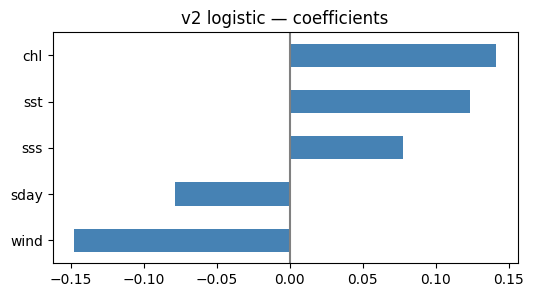


with squared terms:
sday2   -1.57
wind    -0.18
sst2    -0.16
sss      0.07
sst      0.11
chl      0.18
sday     1.25
dtype: float64


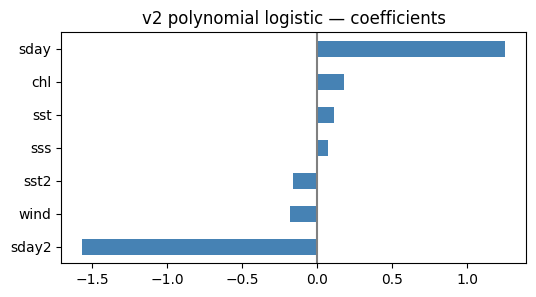

In [11]:
logit2 = LogisticRegression(max_iter=1000).fit(Xtr1, y2_tr)
p_val_l2 = logit2.predict_proba(Xva1)[:, 1]
print("linear:"); coef_plot(logit2, FEATS, "v2 logistic — coefficients")

logit2p = LogisticRegression(max_iter=1000).fit(Xtr2, y2_tr)
p_val_l2p = logit2p.predict_proba(Xva2)[:, 1]
print("\nwith squared terms:"); coef_plot(logit2p, FEATS2, "v2 polynomial logistic — coefficients")

*Reading:* Day of season dominates through its squared term (`sday²` = −1.57, `sday` = +1.25): the bell shape of the season. **Wind** is the largest environmental coefficient and has the expected sign (−0.15 linear, −0.18 with squared terms: more wind, fewer good days). SST, chlorophyll and salinity stay close to zero (|coef| ≤ 0.18). Direction right, size small.

### 3.3 Small neural network for classification (Week 6)
One hidden layer; manual search over its width (4, 8, 16 units). Same inputs as the polynomial model. The validation set picks the width (16 units, equal to 8 on validation).

In [12]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(0); np.random.seed(0)

def make_nn(units):
    m = keras.Sequential([
        keras.layers.Input(shape=(Xtr2.shape[1],)),
        keras.layers.Dense(units, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

nn_models, nn_val = {}, {}
for units in [4, 8, 16]:
    m = make_nn(units)
    h = m.fit(Xtr2, y2_tr, epochs=100, batch_size=32, verbose=0, validation_data=(Xva2, y2_va))
    nn_models[units] = m
    nn_val[units] = m.predict(Xva2, verbose=0).ravel()
    print(f"{units:2d} units | train acc {h.history['accuracy'][-1]:.2f} | val acc {h.history['val_accuracy'][-1]:.2f}")

 4 units | train acc 0.68 | val acc 0.60
 8 units | train acc 0.68 | val acc 0.59


16 units | train acc 0.69 | val acc 0.60


### 3.4 Threshold tuning on the validation set — all models at equal thresholds

In [13]:
for thr in [0.3, 0.4, 0.5]:
    score(y2_va, p_val_base2, thr, f"baseline thr {thr}")
    score(y2_va, p_val_l2,    thr, f"logistic thr {thr}")
    score(y2_va, p_val_l2p,   thr, f"poly-logistic thr {thr}")
    for units in [4, 8, 16]:
        score(y2_va, nn_val[units], thr, f"nn {units:2d} units thr {thr}")
    print()
score(y2_va, np.zeros(len(val)), label="always 'no' (val)")

baseline thr 0.3           acc 0.58 | TP  57 FP  55 FN  22 TN  48
logistic thr 0.3           acc 0.59 | TP  66 FP  61 FN  13 TN  42
poly-logistic thr 0.3      acc 0.60 | TP  62 FP  55 FN  17 TN  48
nn  4 units thr 0.3        acc 0.52 | TP  57 FP  66 FN  22 TN  37
nn  8 units thr 0.3        acc 0.64 | TP  57 FP  44 FN  22 TN  59
nn 16 units thr 0.3        acc 0.64 | TP  49 FP  36 FN  30 TN  67

baseline thr 0.4           acc 0.55 | TP  34 FP  36 FN  45 TN  67
logistic thr 0.4           acc 0.58 | TP  11 FP   9 FN  68 TN  94
poly-logistic thr 0.4      acc 0.66 | TP  38 FP  20 FN  41 TN  83
nn  4 units thr 0.4        acc 0.59 | TP  17 FP  13 FN  62 TN  90
nn  8 units thr 0.4        acc 0.63 | TP  31 FP  20 FN  48 TN  83
nn 16 units thr 0.4        acc 0.61 | TP  23 FP  15 FN  56 TN  88

baseline thr 0.5           acc 0.57 | TP   0 FP   0 FN  79 TN 103
logistic thr 0.5           acc 0.57 | TP   1 FP   1 FN  78 TN 102
poly-logistic thr 0.5      acc 0.59 | TP   6 FP   2 FN  73 TN 101
nn  4 un

0.5659340659340659

*Reading:* With wind among the inputs, the best validation score rises from 0.61 (without wind) to **0.66** — polynomial logistic at threshold 0.4: 38 good days found out of 79, with 20 empty trips. The 8- and 16-unit networks reach 0.64 at threshold 0.3. The trivial answer ("always no") is 0.57 and the weekly baseline never exceeds 0.58. The gain is modest (+5 points) but it is the first improvement that comes from an environmental variable rather than from the calendar. Training accuracy of the networks is 0.68–0.69, so they are not overfitting: there is simply little to learn. Threshold 0.4 and the 16-unit network (equal to 8 units on validation) are chosen for the test.

### 3.5 Test (used once)
Best model and threshold chosen on the validation set above — set them here before running.

In [14]:
THR      = 0.4          # chosen on validation
NN_UNITS = 16           # chosen on validation

p_test_l2p = logit2p.predict_proba(Xte2)[:, 1]
p_test_nn  = nn_models[NN_UNITS].predict(Xte2, verbose=0).ravel()

score(y2_te, p_test_base2, THR, f"baseline thr {THR} (test)")
score(y2_te, p_test_l2p,   THR, f"poly-logistic thr {THR} (test)")
score(y2_te, p_test_nn,    THR, f"nn {NN_UNITS} units thr {THR} (test)")
score(y2_te, np.zeros(len(test)), label="always 'no' (test)")

baseline thr 0.4 (test)    acc 0.52 | TP  45 FP  60 FN  70 TN  98
poly-logistic thr 0.4 (test) acc 0.63 | TP  39 FP  25 FN  76 TN 133
nn 16 units thr 0.4 (test) acc 0.66 | TP  64 FP  42 FN  51 TN 116
always 'no' (test)         acc 0.58 | TP   0 FP   0 FN 115 TN 158


0.5787545787545788

*Reading (test, 2007–2009, threshold 0.4):* Neural network **0.66**, polynomial logistic **0.63**, "always no" 0.58, weekly baseline 0.52. The network flags 106 days as good and is right on 64 of them (60%) against a base rate of 42%; the logistic is more cautious (64 flagged, 61% right). Without wind both models scored 0.61 on the same test set, so the fast-changing variable adds 2–5 points — small, but the first gain that does not come from the calendar.

## 4. Conclusions

**Version 1 — "at least one sighting?"** In the peak season 80–90% of days have a sighting, so every model converged on "always yes". Not a model failure: the question has no information left in it, and operators already go out every day in season.

**Version 2 — "better-than-average day?"** A fair question (37% of days, stable across seasons because each season is compared with itself). With SST, chlorophyll and salinity only, no model beats "always no" (0.58) by more than 3 points, and that gain comes from the shape of the season (`sday²`), not from the environment. **Adding wind speed** — the only fast-changing input — gives the first environmental variable with a clear sign (more wind, fewer good days) and lifts the test score to 0.63 (polynomial logistic) and 0.66 (neural network): a modest but real gain over the calendar.

**Models.** The three course models agree. Linear logistic cannot describe a season that rises and falls; squared terms fix that; the neural network finds nothing the polynomial logistic does not (training accuracy 0.68, no overfitting — there is simply little more to learn in these inputs).

**What this means.** Slow satellite variables describe *when* the season is; a fast one starts to say *which day* inside it will be good. The effect is small at Ningaloo, where strong-wind days are rare, the reef shelters the boats, and daily mean wind is a coarse proxy for sea state. This is the EDA result confirmed by a predictive test, and it agrees with the daily-scale studies with effort data (Rohner 2013, Swai 2024): inside the season, only fast-changing variables add anything.

**Limitations.** Days without a record are treated as "no sighting", which also means "no boat". Accuracy is the course metric; with 37–43% positives it is a fair comparison only at equal thresholds and against the majority class, which is how every table above is built.

**Next steps**
1. Better sea-state proxies: wind averaged over the previous 2–3 days; wave height from Copernicus.
2. Philippines and Tofo with the same notebook (Tofo faces the open ocean: the wind effect should be stronger); cross-site test (train on one site, test on another).
3. Effort: Cagua 2015 search-hours at Mafia to separate "no sharks" from "no boat".